In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv('level_salary_polynomial.csv')
dataset.head(3)

,Level,Salary
0,1,1798
1,2,3981
2,3,7874


Text(0, 0.5, 'Salary')

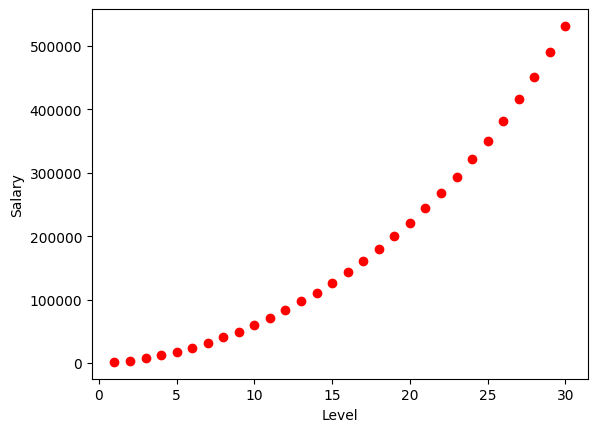

In [6]:
plt.scatter(dataset.Level, dataset.Salary, color='red')
plt.xlabel('Level')
plt.ylabel('Salary')

In [4]:
dataset.corr()  

,Level,Salary
Level,1.000000,0.964526
Salary,0.964526,1.000000


In [7]:
# To convert in Polynomial Features
x = dataset[["Level"]]
y = dataset["Salary"]

In [8]:
from sklearn.preprocessing import PolynomialFeatures

In [9]:
pf = PolynomialFeatures(degree=2)
pf.fit(x)
pf.transform(x)

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.],
       [  1.,  11., 121.],
       [  1.,  12., 144.],
       [  1.,  13., 169.],
       [  1.,  14., 196.],
       [  1.,  15., 225.],
       [  1.,  16., 256.],
       [  1.,  17., 289.],
       [  1.,  18., 324.],
       [  1.,  19., 361.],
       [  1.,  20., 400.],
       [  1.,  21., 441.],
       [  1.,  22., 484.],
       [  1.,  23., 529.],
       [  1.,  24., 576.],
       [  1.,  25., 625.],
       [  1.,  26., 676.],
       [  1.,  27., 729.],
       [  1.,  28., 784.],
       [  1.,  29., 841.],
       [  1.,  30., 900.]])

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
lr.score(x_test, y_test)

0.9303080508193957

In [ ]:
# y = m1*1 + m2*2 + c


In [19]:
lr.coef_

array([17246.85211996])

In [16]:
pr = lr.predict(x)

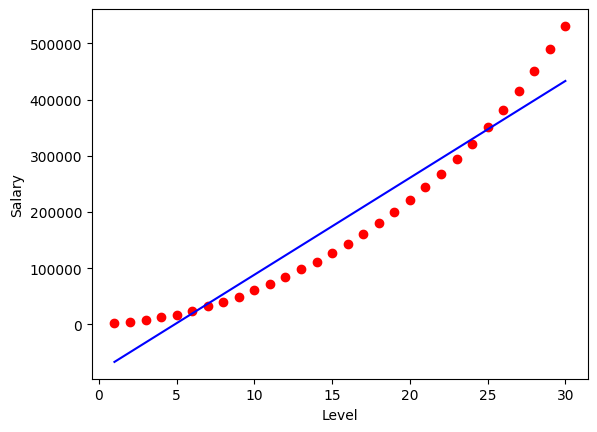

In [ ]:
plt.scatter(dataset.Level, dataset.Salary, color='red')
plt.plot(dataset["Level"], pr, color='blue')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend(['Predicted line', 'Actual Data'])
plt.show()

In [23]:
test = pf.transform([[15]])
test

C:\Users\Harnoor kaur\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[  1.,  15., 225.]])

In [24]:
lr.predict(test)

C:\Users\Harnoor kaur\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: X has 3 features, but LinearRegression is expecting 1 features as input.